In [1]:
import pandas as pd
df = pd.read_csv("/content/Walmart_Sales.csv")
print(df.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [3]:
df.shape

(6435, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [7]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [10]:
#average weekly_sales
df['Weekly_Sales'].mean()

np.float64(1046964.8775617715)

In [11]:
#highest weekly_sales
df['Weekly_Sales'].max()

3818686.45

In [12]:
#lowest weekly_sales
df['Weekly_Sales'].min()

209986.25

In [13]:
#total weekly_sales
df['Weekly_Sales'].sum()

np.float64(6737218987.11)

In [14]:
df['Weekly_Sales'].median()

960746.04

In [15]:
df['Weekly_Sales'].mode()

,Weekly_Sales
0,209986.25
1,213538.32
2,215359.21
3,219804.85
4,220060.35
...,...
6430,3595903.20
6431,3676388.98
6432,3749057.69
6433,3766687.43


In [16]:
df.groupby("Store")["Weekly_Sales"].sum()

,Weekly_Sales
Store,
1,2.224028e+08
2,2.753824e+08
3,5.758674e+07
4,2.995440e+08
5,4.547569e+07
6,2.237561e+08
7,8.159828e+07
8,1.299512e+08
9,7.778922e+07


In [17]:
df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


#Business Insights 1:


*   Store 20 generated the hightest total sales (~~ 301.4 million)
*   Store 33 generated the lowest total sales (~~ 37.2 million)



In [19]:
df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


#Business Insights 2:

Average weekly sales are highest during holiday weeks than during non-holiday weeks. This suggests that holiday have a positive impact on Walmart's Weekly sales.

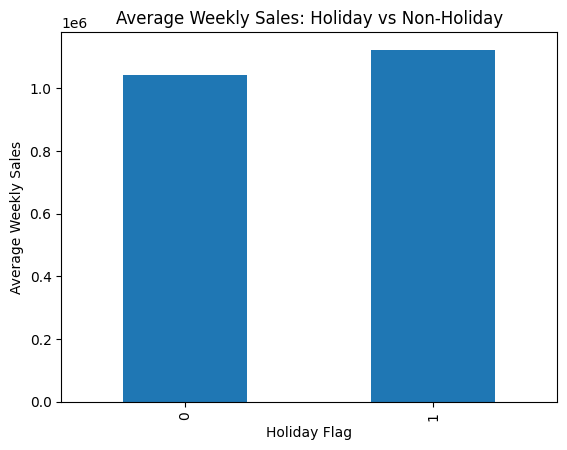

In [20]:
import matplotlib.pyplot as plt
df.groupby("Holiday_Flag")["Weekly_Sales"].mean().plot(kind ="bar")
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Weekly Sales")
plt.show()

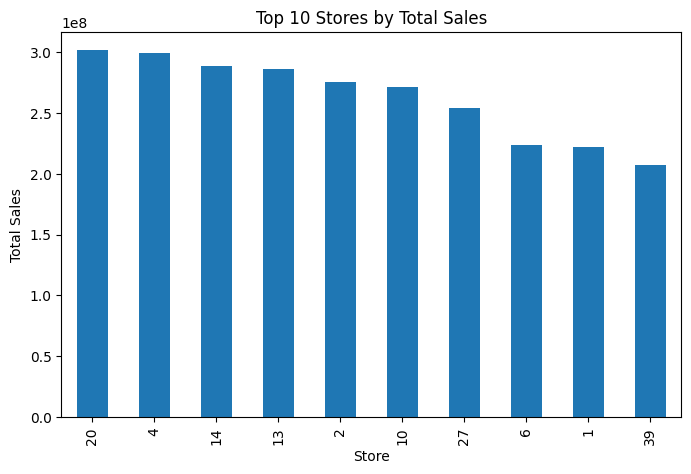

In [21]:
#Top 10 stores by TOTAL SALES
import matplotlib.pyplot as plt
top10 = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10)

top10.plot(kind="bar", figsize=(8,5))
plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

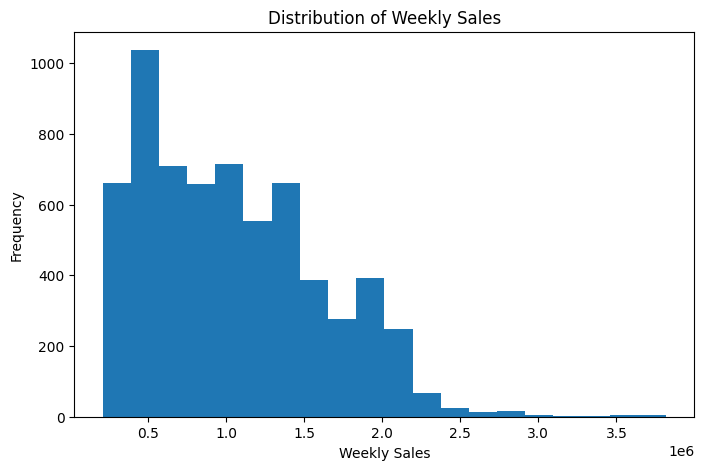

In [23]:
#Histogram of Weekly_Sales
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["Weekly_Sales"], bins=20)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()


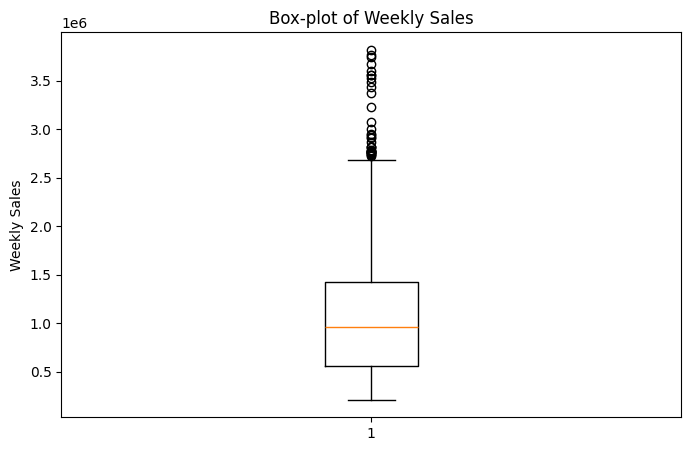

In [24]:
#Box-plot (Outlier detection)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(df["Weekly_Sales"])
plt.title("Box-plot of Weekly Sales")
plt.ylabel("Weekly Sales")
plt.show()

#Box plot interpretation:



*   The median weekly sales are around 1 million
*   The box contains the middle of 50% of the sales values
*   There are many points above the upper whisker, which are      high-value outliers. These likely represent weeks with unsusually high sales(for example, major shopping periods or peak-performing stores)



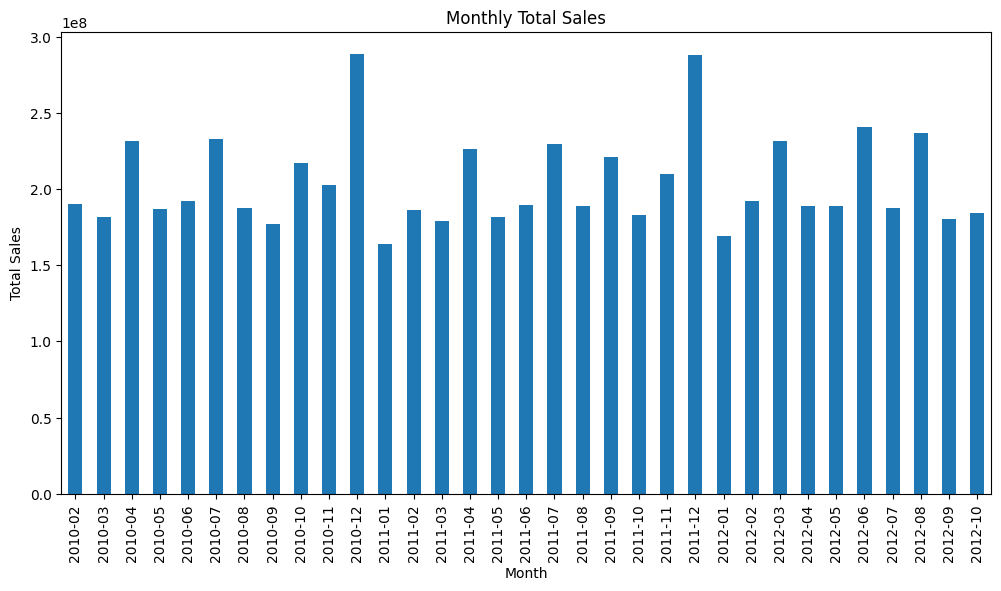

In [26]:
#Time-based by using the DATE column
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Weekly_Sales"].sum()
monthly_sales.plot(kind="bar", figsize=(12,6))
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

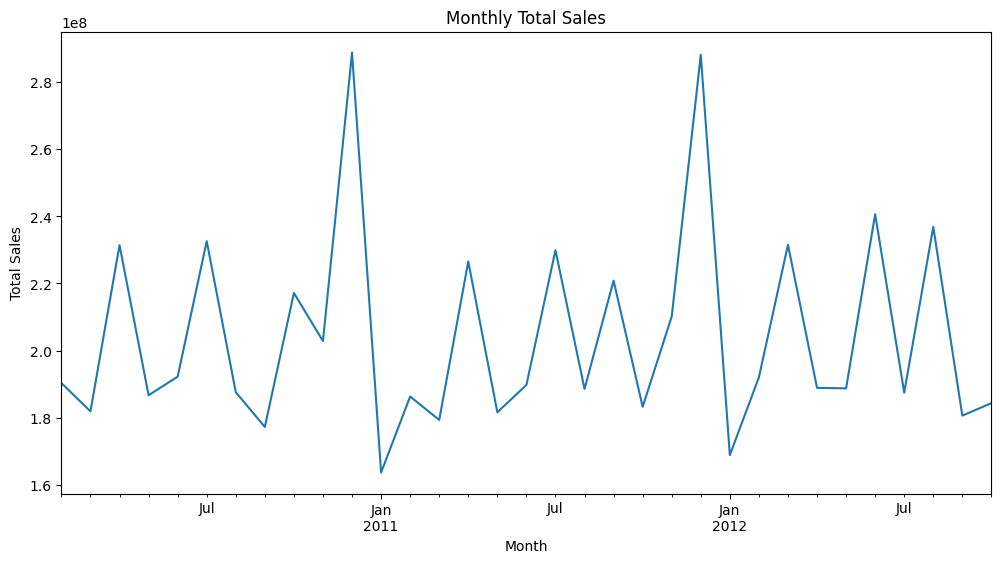

In [27]:
# Line chart
monthly_sales.plot(kind="line", figsize=(12,6))
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


# Final Business Insights:

Dataset Overview


*   The dataset contains 6435 records and 8 columns
*   No missing values were found, so the dataset was clean and ready for analysis.


Key Findings:



1.   The average weekly sales were approximately 1.05 million.
2.   Store 20 recorded the highest weekly sales, While Store 33 recorded the lowest total sales.
3. Holiday weeks had higher average weekly sales than non-holiday weeks, indicating that holidays positively impact sales.
4. Most weekly sales were concentrated between moderate values, while only a few weeks recorded exceptionally high sales.
5. The box plot revealed several high-value outliers, representing unusually high sales during certain weeks.
6. Monthly Sales fluctuated throughout the period, suggesting seasonal or event-driven changes in customer demand.
7. The Top 10 stores analysis showed that a small number of stores consistently generated significantly higher sales than others.


Conclusion:  This analysis demonstrates how Pyhon, Pndas and Matplotlib can be used to explore sales data, identify business trends, compare store performance, and generate actionable insights. The result can help business understand sales patterns and support  better decision-making.


